In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

cwd = Path.cwd()
csv_path = cwd / 'data' / 'SAM-1000L-B7H4-experiment'

# Load the first CSV file
df1 = pd.read_csv(csv_path / 'online_data_raman.csv')

# Load the second CSV file
df2 = pd.read_csv(csv_path / 'offline_data_raman.csv')

# Display the first few rows of each DataFrame
print("First DataFrame:")
print(df1.head())

print("\nSecond DataFrame:")
print(df2.head())

First DataFrame:
              Time          PV
0  11/21/2025 8:30 -132.008545
1  11/21/2025 8:45 -131.084228
2  11/21/2025 9:00 -129.161377
3  11/21/2025 9:15 -131.403564
4  11/21/2025 9:30 -138.585327

Second DataFrame:
               Time  Titer      SP
0  11/21/2025 10:18   22.4   21.05
1   11/22/2025 9:00   38.1   33.39
2   11/23/2025 8:07   69.6   60.40
3   11/24/2025 8:44  136.0  122.91
4   11/25/2025 8:23  267.4  236.89


Updated df1:
                 Time          PV  Elapsed_Time_Days  CSP_lin  PV_Smoothed
0 2025-11-21 08:30:00 -132.008545          -0.075000    21.05          NaN
1 2025-11-21 08:45:00 -131.084228          -0.064583    21.05          NaN
2 2025-11-21 09:00:00 -129.161377          -0.054167    21.05  -130.914429
3 2025-11-21 09:15:00 -131.403564          -0.043750    21.05  -132.558624
4 2025-11-21 09:30:00 -138.585327          -0.033333    21.05  -136.172089

Updated df2:
                 Time  Titer      SP  Elapsed_Time_Days
0 2025-11-21 10:18:00   22.4   21.05           0.000000
1 2025-11-22 09:00:00   38.1   33.39           0.945833
2 2025-11-23 08:07:00   69.6   60.40           1.909028
3 2025-11-24 08:44:00  136.0  122.91           2.934722
4 2025-11-25 08:23:00  267.4  236.89           3.920139
Smoothed df1:
                 Time          PV  Elapsed_Time_Days  CSP_lin  PV_Smoothed
0 2025-11-21 08:30:00 -132.008545          -0.075000    21.05          NaN
1 2025-11-21 08:45:00 -

C:\Users\zah48132\AppData\Local\Temp\ipykernel_34748\255649876.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left')


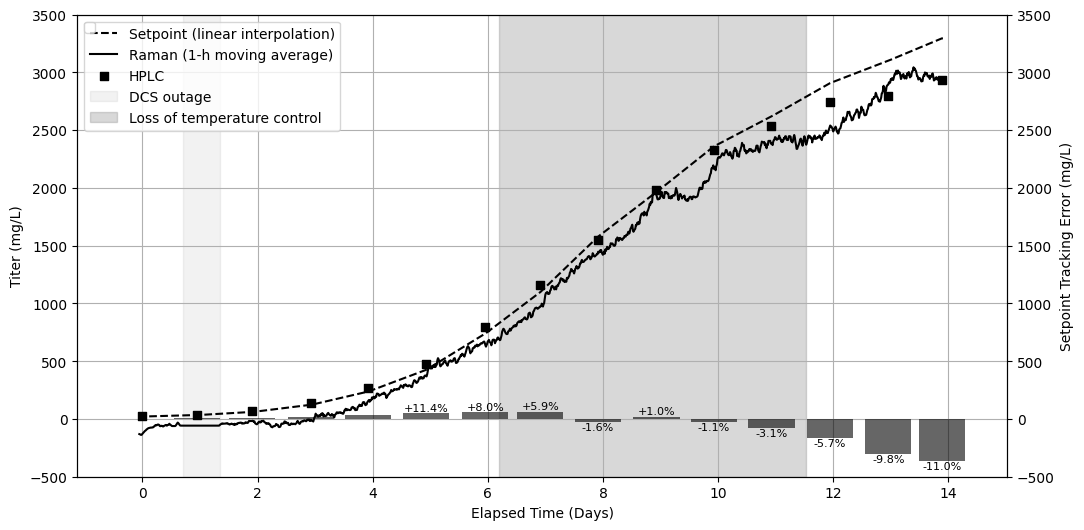

In [8]:
# Convert the Time columns to datetime format
df1['Time'] = pd.to_datetime(df1['Time'])
df2['Time'] = pd.to_datetime(df2['Time'])

# Get the reference time from the first timestamp in df2.Time
reference_time = df2['Time'].iloc[0]

# Calculate the elapsed time in minutes for both DataFrames
df1['Elapsed_Time_Days'] = (df1['Time'] - reference_time).dt.total_seconds() / (60 * 60 * 24)
df2['Elapsed_Time_Days'] = (df2['Time'] - reference_time).dt.total_seconds() / (60 * 60 * 24)

# Perform linear interpolation of df2.SP on df1.Elapsed_Time_Days
df1['CSP_lin'] = np.interp(df1['Elapsed_Time_Days'], df2['Elapsed_Time_Days'], df2['SP'])

# Display the updated DataFrames
print("Updated df1:")
print(df1.head())

print("\nUpdated df2:")
print(df2.head())

# Smooth df1.PV by a moving average of 1-hour window (4 intervals of 15 minutes each)
df1['PV_Smoothed'] = df1['PV'].rolling(window=4, center=True).mean()

# Display the updated DataFrame
print("Smoothed df1:")
print(df1.head())

# Plot CSP and PV_Smoothed against Elapsed_Time_Days as lines
plt.figure(figsize=(12, 6))
plt.plot(df1['Elapsed_Time_Days'], df1['CSP_lin'], label='Setpoint (linear interpolation)', color='black', linestyle='--', zorder=2)
plt.plot(df1['Elapsed_Time_Days'], df1['PV_Smoothed'], label='Raman (1-h moving average)', color='black', linestyle='-', zorder=2)

# Plot df2.Titer against Elapsed_Time_Days as dots
plt.scatter(df2['Elapsed_Time_Days'], df2['Titer'], label='HPLC', color='black', marker='s', zorder=2)

# Add a transparent shadow rectangle to indicate the period between elapsed time 6 and 11
# Calculate the elapsed times for the given timestamps
timestamp1 = pd.Timestamp('2025-11-27 14:44:00')
timestamp2 = pd.Timestamp('2025-12-02 22:53:00')
timestamp3 = pd.Timestamp('2025-11-22 03:15:00')
timestamp4 = pd.Timestamp('2025-11-22 18:30:00')
elapsed_time1 = (timestamp1 - reference_time).total_seconds() / (60 * 60 * 24)
elapsed_time2 = (timestamp2 - reference_time).total_seconds() / (60 * 60 * 24)
elapsed_time3 = (timestamp3 - reference_time).total_seconds() / (60 * 60 * 24)
elapsed_time4 = (timestamp4 - reference_time).total_seconds() / (60 * 60 * 24)
plt.axvspan(elapsed_time3, elapsed_time4, color='gray', alpha=0.1, label='DCS outage')
plt.axvspan(elapsed_time1, elapsed_time2, color='gray', alpha=0.3, label='Loss of temperature control')

# Add labels, legend, and title
plt.xlabel('Elapsed Time (Days)')
plt.ylabel('Titer (mg/L)')
# plt.title('CSP, PV Smoothed, and Titer over Elapsed Time')
plt.legend()
plt.grid(True, zorder=1)
plt.ylim((-500,3500))

# Plot the absolute difference between Titer and SP as vertical bars on a secondary y-axis
percentage_diff = ((df2['Titer'] - df2['SP']) / df2['SP']) * 100
ax = plt.gca()
ax2 = ax.twinx()
ax2.bar(df2['Elapsed_Time_Days'], (df2['Titer'] - df2['SP']), color='black', alpha=0.6, zorder=2)
# Add percentage_diff values as text inside the bars
for i, (x, y) in enumerate(zip(df2['Elapsed_Time_Days'], df2['Titer'] - df2['SP'])):
    if i >= len(df2) - 10:  # Only add text for the last 10 bars
        ax2.text(x, y, f'{percentage_diff[i]:+.1f}%', ha='center', va='bottom' if y >= 0 else 'top', fontsize=8, color='black')
# ax2.bar(df2['Elapsed_Time_Days'], percentage_diff, color='black', alpha=0.6)
ax2.legend(loc='upper left')
ax2.set_ylabel('Setpoint Tracking Error (mg/L)', color='black')
ax2.set_ylim(ax.get_ylim())
# ax2.set_ylim((-10,70))
ax2.tick_params(axis='y', labelcolor='black')

# Save the figure as a PNG file in the same folder
plt.savefig(csv_path / 'figures/EOR/raman.png', format='png', dpi=300)

# Show the plot
plt.show()

